In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv("../data/leads_data.csv")

In [4]:
df.head()

,lead_id,source,campaign,date,status,region,revenue
0,1,Referral,Referral_Program,2024-01-16,Converted,East,5104
1,2,Google,Referral_Program,2024-03-09,Lost,East,0
2,3,Referral,Referral_Program,2024-02-25,Converted,North,5269
3,4,Referral,Referral_Program,2024-02-13,Qualified,West,0
4,5,Website,FB_Ads,2024-03-20,Contacted,East,0


In [6]:
df.shape   

(1000, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   lead_id   1000 non-null   int64 
 1   source    1000 non-null   object
 2   campaign  1000 non-null   object
 3   date      1000 non-null   object
 4   status    1000 non-null   object
 5   region    1000 non-null   object
 6   revenue   1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [8]:
df.describe()

,lead_id,revenue
count,1000.000000,1000.000000
mean,500.500000,1659.017000
std,288.819436,3006.829525
min,1.000000,0.000000
25%,250.750000,0.000000
50%,500.500000,0.000000
75%,750.250000,3189.250000
max,1000.000000,9999.000000


In [9]:
df.isnull().sum()

lead_id     0
source      0
campaign    0
date        0
status      0
region      0
revenue     0
dtype: int64

In [11]:
df["date"] = pd.to_datetime(df["date"]) 

#extracting mmonth 
df["month"] = df["date"].dt.month

In [15]:
total_leads = len(df)
print(total_leads)

1000


In [19]:
converted = df[df["status"] == "Converted"].shape[0]
conversion_rate =(converted / total_leads) *100 

print(f"Conversion Rate : {conversion_rate: .2f}%")

Conversion Rate :  25.60%


In [21]:
#leads by source 
df["source"].value_counts()

source
Facebook    263
Referral    260
Website     248
Google      229
Name: count, dtype: int64

In [22]:
#conversion rate by source 
conversion = df[df["status"] == "Converted"].groupby("source").size()
total = df.groupby("source").size()

conversion_rate_source = (conversion / total) * 100
conversion_rate_source.sort_values(ascending=False)


source
Google      26.200873
Referral    26.153846
Facebook    25.855513
Website     24.193548
dtype: float64

In [23]:
# Revenue Analysis
df.groupby("source")["revenue"].sum().sort_values(ascending = False)

source
Referral    449678
Facebook    428898
Google      393269
Website     387172
Name: revenue, dtype: int64

In [24]:
#monthly trend 
df.groupby("month")["revenue"].sum()

month
1    531283
2    529870
3    597864
Name: revenue, dtype: int64

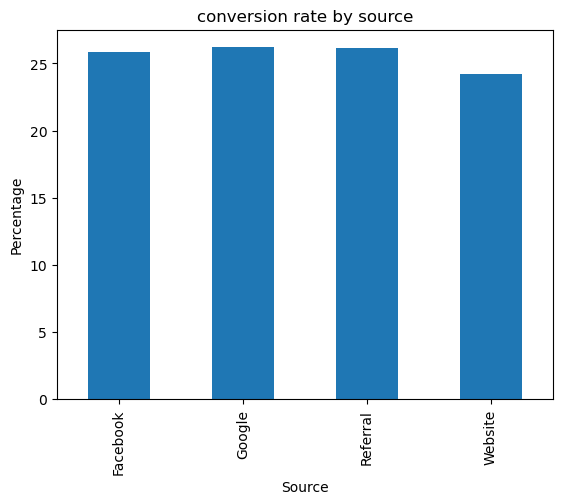

In [26]:
#visualization
conversion_rate_source.plot(kind ="bar") 

plt.title("conversion rate by source")
plt.ylabel("Percentage")
plt.xlabel("Source")

plt.savefig("../visuals/conversion_rate_source.png")
plt.show()

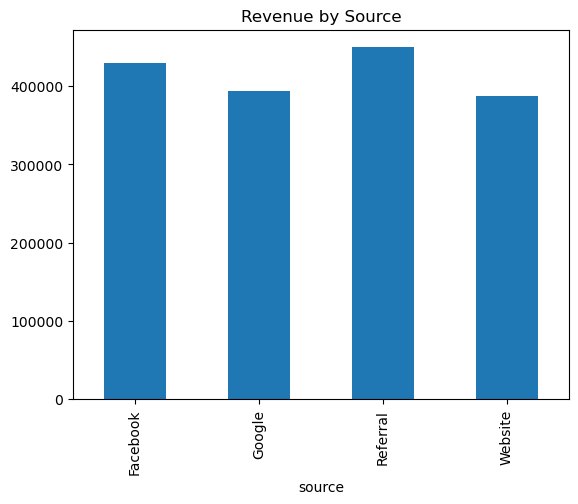

In [28]:
#revenue by source 
df.groupby('source')['revenue'].sum().plot(kind='bar')

plt.title("Revenue by Source")

plt.savefig("../visuals/revenue_source.png")
plt.show()

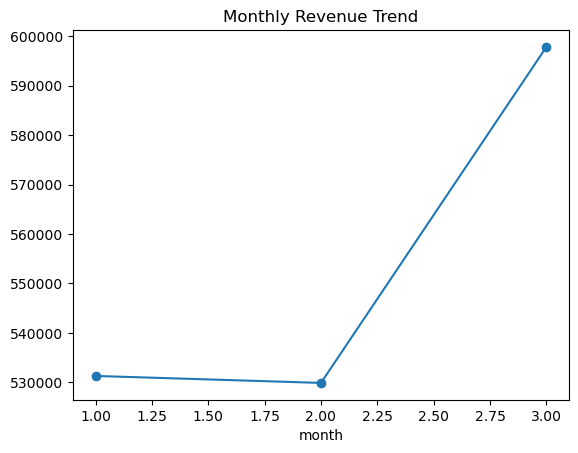

In [30]:
#monthly revenue trned
df.groupby('month')['revenue'].sum().plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.savefig("../visuals/monthly_revenue.png")
plt.show()

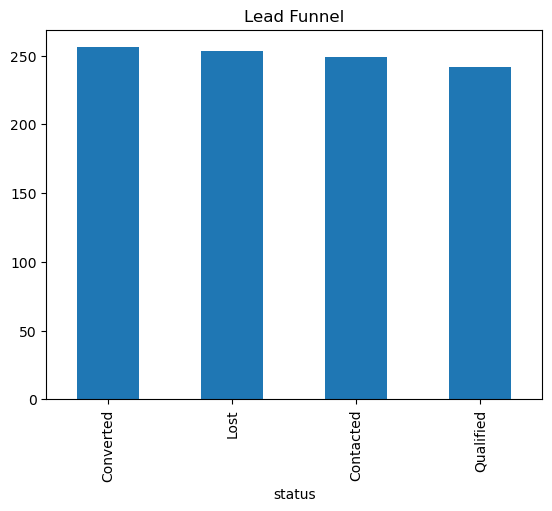

In [31]:
#funnel analysis 
df['status'].value_counts().plot(kind='bar')

plt.title("Lead Funnel")
plt.show()